# Micro Proyecto 1 — Generación de Música con LSTM
Compositor seleccionado: **Ludwig van Beethoven**

In [32]:
# False → local  |  True → Google Colab
COLAB = True

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install pretty_midi


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
torch.manual_seed(42)


## 1. Cargar archivos MIDI

In [34]:
if COLAB:
    DATA_PATH = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/data/music_artist/beeth'
else:
    DATA_PATH = './data/music_artist/beeth'

midi_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos encontrados: {len(midi_files)}')

TARGET_INSTRUMENT = 'Acoustic Grand Piano'

def extract_notes(instrument):
    rows, prev_start, prev_pitch = [], None, None
    for note in sorted(instrument.notes, key=lambda x: x.start):
        duration = note.end - note.start
        step     = note.start - prev_start if prev_start is not None else 0.0
        gap      = step - duration
        interval = note.pitch - prev_pitch if prev_pitch is not None else 0
        rows.append({'pitch': note.pitch, 'duration': duration, 'gap': gap,
                     'velocity': note.velocity, 'interval': interval})
        prev_start = note.start
        prev_pitch = note.pitch
    return rows

# song_groups: basename → lista de secuencias (DataFrames) de esa canción
song_groups      = defaultdict(list)  # basename → [seq_df, ...]
song_group_names = defaultdict(list)  # basename → [name, ...]
all_notes        = []

for f in midi_files:
    pm   = pretty_midi.PrettyMIDI(f)
    base = os.path.basename(f)
    for i, inst in enumerate(pm.instruments):
        if pretty_midi.program_to_instrument_name(inst.program) != TARGET_INSTRUMENT:
            continue
        notes = extract_notes(inst)
        if len(notes) < 10:        # descartar pistas triviales
            continue
        song_groups[base].append(pd.DataFrame(notes))
        song_group_names[base].append(f'{base} — inst {i}')
        all_notes.extend(notes)

song_keys = sorted(song_groups.keys())
print(f'Canciones únicas: {len(song_keys)}')
for k in song_keys:
    print(f'  {k}: {len(song_groups[k])} secuencia(s)')

df = pd.DataFrame(all_notes)
print(f'\nNotas totales: {len(df):,}')


Archivos encontrados: 29
Canciones únicas: 23
  appass_1.mid: 2 secuencia(s)
  appass_2.mid: 2 secuencia(s)
  appass_3.mid: 2 secuencia(s)
  beethoven_hammerklavier_1.mid: 2 secuencia(s)
  beethoven_hammerklavier_2.mid: 2 secuencia(s)
  beethoven_hammerklavier_3.mid: 2 secuencia(s)
  beethoven_hammerklavier_4.mid: 2 secuencia(s)
  beethoven_les_adieux_1.mid: 2 secuencia(s)
  beethoven_les_adieux_2.mid: 2 secuencia(s)
  beethoven_les_adieux_3.mid: 2 secuencia(s)
  beethoven_opus10_1.mid: 2 secuencia(s)
  beethoven_opus10_2.mid: 2 secuencia(s)
  beethoven_opus10_3.mid: 2 secuencia(s)
  beethoven_opus22_1.mid: 2 secuencia(s)
  beethoven_opus22_2.mid: 2 secuencia(s)
  beethoven_opus22_3.mid: 2 secuencia(s)
  beethoven_opus22_4.mid: 2 secuencia(s)
  beethoven_opus90_1.mid: 2 secuencia(s)
  beethoven_opus90_2.mid: 2 secuencia(s)
  elise.mid: 2 secuencia(s)
  mond_1.mid: 3 secuencia(s)
  mond_2.mid: 2 secuencia(s)
  mond_3.mid: 2 secuencia(s)

Notas totales: 84,785


## 2. Codificación de Pitch

Descomponemos cada MIDI pitch en:
- **`pitch_class`** = `pitch % 12` — identidad armónica (0–11)
- **`octave_idx`**  = `pitch // 12` — registro (0–10, índice de embedding)

Reconstrucción: `pitch = 12 × octave_idx + pitch_class`

In [35]:
pitch_table = pd.DataFrame({
    'pitch':       range(128),
    'note_name':   [pretty_midi.note_number_to_name(p) for p in range(128)],
    'pitch_class': [p % 12        for p in range(128)],
    'octave':      [(p // 12) - 1 for p in range(128)],
    'octave_idx':  [p // 12       for p in range(128)],
})

PITCH_CLASS_VOCAB = 12
OCTAVE_VOCAB      = 11

print('Muestra de la tabla de codificación MIDI:')
display(pitch_table.iloc[[0, 12, 24, 36, 48, 60, 69, 72, 84, 96, 108, 127]])
print(f'\npitch_class vocab: {PITCH_CLASS_VOCAB}  |  octave vocab: {OCTAVE_VOCAB}')


Muestra de la tabla de codificación MIDI:


,pitch,note_name,pitch_class,octave,octave_idx
0,0,C-1,0,-1,0
12,12,C0,0,0,1
24,24,C1,0,1,2
36,36,C2,0,2,3
48,48,C3,0,3,4
60,60,C4,0,4,5
69,69,A4,9,4,5
72,72,C5,0,5,6
84,84,C6,0,6,7
96,96,C7,0,7,8



pitch_class vocab: 12  |  octave vocab: 11


## 3. Preparación del dataset

In [36]:
# ── 3.1  Split por CANCIÓN (no por secuencia suelta) ───────────────────────
# Ambas manos de una misma obra siempre quedan en el mismo split.
#
# Estrategia:
#   - TEST_SONGS canciones fijas → test (evaluación final, nunca durante entrenamiento)
#   - Del resto: 10 % → val (early stopping, scheduler), 90 % → train
# Semilla fija para reproducibilidad.

SEED_SPLIT  = 42
TEST_SONGS  = 3

rng = np.random.default_rng(SEED_SPLIT)
shuffled = rng.permutation(song_keys).tolist()

test_song_keys  = shuffled[:TEST_SONGS]
remain_keys     = shuffled[TEST_SONGS:]

n_val           = max(1, round(len(remain_keys) * 0.10))
val_song_keys   = remain_keys[:n_val]
train_song_keys = remain_keys[n_val:]

def flatten_songs(keys):
    seqs, names = [], []
    for k in keys:
        seqs.extend(song_groups[k])
        names.extend(song_group_names[k])
    return seqs, names

train_seqs, train_names = flatten_songs(train_song_keys)
val_seqs,   val_names   = flatten_songs(val_song_keys)
test_seqs,  test_names  = flatten_songs(test_song_keys)

print(f'Split (canciones):  train={len(train_song_keys)}  val={len(val_song_keys)}  test={len(test_song_keys)}')
print(f'Split (secuencias): train={len(train_seqs)}       val={len(val_seqs)}       test={len(test_seqs)}')

print('\n── TRAIN ──')
for k in train_song_keys: print(f'  {k}: {len(song_groups[k])} seq')
print('\n── VAL ──')
for k in val_song_keys:   print(f'  {k}: {len(song_groups[k])} seq')
print('\n── TEST ──')
for k in test_song_keys:  print(f'  {k}: {len(song_groups[k])} seq')

# ── 3.1b  Augmentation: transposición de tono (solo train) ──────────────────
TRANSPOSE_SEMITONES = [-4, -2, -1, 1, 2, 4]
augmented = []
for seq in train_seqs:
    for delta in TRANSPOSE_SEMITONES:
        aug = seq.copy()
        aug['pitch'] = (aug['pitch'] + delta).clip(0, 127)
        augmented.append(aug)
train_seqs_aug = train_seqs + augmented
print(f'\nTrain tras augmentación: {len(train_seqs_aug)} seqs  '
      f'({sum(len(s) for s in train_seqs_aug):,} notas)')


Split (canciones):  train=18  val=2  test=3
Split (secuencias): train=37       val=4       test=6

── TRAIN ──
  beethoven_opus22_3.mid: 2 seq
  beethoven_les_adieux_1.mid: 2 seq
  beethoven_hammerklavier_4.mid: 2 seq
  beethoven_les_adieux_3.mid: 2 seq
  beethoven_hammerklavier_1.mid: 2 seq
  appass_1.mid: 2 seq
  elise.mid: 2 seq
  beethoven_opus10_3.mid: 2 seq
  beethoven_hammerklavier_3.mid: 2 seq
  beethoven_opus10_2.mid: 2 seq
  beethoven_opus22_2.mid: 2 seq
  mond_2.mid: 2 seq
  appass_3.mid: 2 seq
  beethoven_hammerklavier_2.mid: 2 seq
  mond_1.mid: 3 seq
  appass_2.mid: 2 seq
  beethoven_opus22_1.mid: 2 seq
  beethoven_les_adieux_2.mid: 2 seq

── VAL ──
  mond_3.mid: 2 seq
  beethoven_opus22_4.mid: 2 seq

── TEST ──
  beethoven_opus90_2.mid: 2 seq
  beethoven_opus10_1.mid: 2 seq
  beethoven_opus90_1.mid: 2 seq

Train tras augmentación: 259 seqs  (456,596 notas)


In [37]:
# ── 3.2  Normalización ───────────────────────────────────────────────────────
# pitch_class / octave_idx → enteros (Embedding, sin normalizar)
# duration_log (log1p), gap, velocity  → MinMaxScaler [0, 1]
# El scaler se ajusta SOLO sobre train (sin datos de val / test).

train_all     = pd.concat(train_seqs_aug)
DURATION_CLIP = train_all['duration'].quantile(0.99)
GAP_LO_CLIP   = train_all['gap'].quantile(0.01)
GAP_HI_CLIP   = train_all['gap'].quantile(0.99)
print(f'Clip duration p99:     {DURATION_CLIP:.4f} s')
INTERVAL_CLIP = 24   # ±2 octavas; cubre >99 % de los intervalos reales
print(f'Clip gap [p01, p99]: [{GAP_LO_CLIP:.4f}, {GAP_HI_CLIP:.4f}] s')
print(f'Clip interval:       ±{INTERVAL_CLIP} semitonos')

train_clipped             = train_all.copy()
train_clipped['duration'] = train_clipped['duration'].clip(0, DURATION_CLIP)
train_clipped['gap']      = train_clipped['gap'].clip(GAP_LO_CLIP, GAP_HI_CLIP)
train_clipped['duration_log'] = np.log1p(train_clipped['duration'])
scaler = MinMaxScaler().fit(train_clipped[['duration_log', 'gap', 'velocity']])

def normalize_seq(seq_df):
    """Array (N, 6): [pitch_class, octave_idx, duration_log_norm, gap_norm, velocity_norm, interval_norm]"""
    arr = seq_df.copy()
    arr['pitch_class'] = (arr['pitch'] % 12).astype(int)
    arr['octave_idx']  = (arr['pitch'] // 12).astype(int)
    arr['duration']    = arr['duration'].clip(0, DURATION_CLIP)
    arr['gap']         = arr['gap'].clip(GAP_LO_CLIP, GAP_HI_CLIP)
    arr['duration_log'] = np.log1p(arr['duration'])
    arr[['duration_log', 'gap', 'velocity']] = scaler.transform(arr[['duration_log', 'gap', 'velocity']])
    arr['interval_norm'] = arr['interval'].clip(-INTERVAL_CLIP, INTERVAL_CLIP) / INTERVAL_CLIP
    return arr[['pitch_class', 'octave_idx', 'duration_log', 'gap', 'velocity', 'interval_norm']].values

train_arrays = [normalize_seq(s) for s in train_seqs_aug]
val_arrays   = [normalize_seq(s) for s in val_seqs]
test_arrays  = [normalize_seq(s) for s in test_seqs]

# ── 3.2b  Bins equiprobables para duration y gap ────────────────────────────
N_BINS = 16
all_dur = np.concatenate([a[:, 2] for a in train_arrays])
all_gap = np.concatenate([a[:, 3] for a in train_arrays])
dur_edges_norm = np.quantile(all_dur, np.linspace(0, 1, N_BINS + 1)); dur_edges_norm[-1] += 1e-9
gap_edges_norm = np.quantile(all_gap, np.linspace(0, 1, N_BINS + 1)); gap_edges_norm[-1] += 1e-9
dur_centers_norm = (dur_edges_norm[:-1] + dur_edges_norm[1:]) / 2
gap_centers_norm = (gap_edges_norm[:-1] + gap_edges_norm[1:]) / 2

print(f'Ejemplo de nota normalizada [pc, oct, dur_log, gap, vel, int]: {train_arrays[0][0]}')


Clip duration p99:     1.9873 s
Clip gap [p01, p99]: [-1.7563, 1.0997] s
Clip interval:       ±24 semitonos
Ejemplo de nota normalizada [pc, oct, dur_log, gap, vel, int]: [2.         5.         0.29080509 0.48143294 0.33628319 0.        ]


In [38]:
# ── 3.3  DataLoader ──────────────────────────────────────────────────────────
BLOCK_SIZE = 100
BATCH_SIZE = 64

class MusicDataLoader:
    def __init__(self, sequences, block_size):
        self.block_size = block_size
        self.sequences  = [torch.tensor(s, dtype=torch.float32) for s in sequences]
        self.indices    = [(si, st) for si, seq in enumerate(self.sequences)
                           for st in range(len(seq) - block_size)]
        self.order, self.curr_pos = np.random.permutation(len(self.indices)), 0

    def get_batch(self, batch_size):
        batch_idx = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_idx)
        if len(batch_idx) < batch_size:
            self.curr_pos = 0
            self.order    = np.random.permutation(len(self.indices))
            if len(batch_idx) == 0:
                batch_idx = self.order[:batch_size]; self.curr_pos = batch_size
        xs, ys = [], []
        for i in batch_idx:
            si, st = self.indices[i]
            seq    = self.sequences[si]
            xs.append(seq[st : st + self.block_size])
            ys.append(seq[st + self.block_size])
        return torch.stack(xs), torch.stack(ys)

    @property
    def n_examples(self): return len(self.indices)

train_loader = MusicDataLoader(train_arrays, BLOCK_SIZE)
val_loader   = MusicDataLoader(val_arrays,   BLOCK_SIZE)
test_loader  = MusicDataLoader(test_arrays,  BLOCK_SIZE)
x_s, y_s = train_loader.get_batch(BATCH_SIZE)
print(f'Ventanas: train={train_loader.n_examples:,}  val={val_loader.n_examples:,}  test={test_loader.n_examples:,}')
print(f'x: {tuple(x_s.shape)}  →  (batch, contexto, [pc, oct_idx, dur, gap, vel, interval])')
print(f'y: {tuple(y_s.shape)}  →  nota objetivo')


Ventanas: train=430,696  val=9,640  test=8,917
x: (64, 100, 6)  →  (batch, contexto, [pc, oct_idx, dur, gap, vel, interval])
y: (64, 6)  →  nota objetivo


## 4. Modelo LSTM

In [39]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

EMBED_DIM_CLASS = 16
EMBED_DIM_OCT   = 8
HIDDEN_SIZE     = 512
NUM_LAYERS      = 3
DROPOUT         = 0.4
DROPOUT_OUT     = 0.4

class MusicLSTM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.pitch_emb_class = torch.nn.Embedding(PITCH_CLASS_VOCAB, EMBED_DIM_CLASS)
        self.pitch_emb_oct   = torch.nn.Embedding(OCTAVE_VOCAB,      EMBED_DIM_OCT)
        # Input: emb_class(16) + emb_oct(8) + dur(1) + gap(1) + vel(1) + interval(1) = 28
        self.lstm = torch.nn.LSTM(
            input_size  = EMBED_DIM_CLASS + EMBED_DIM_OCT + 4,
            hidden_size = HIDDEN_SIZE,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT,
        )
        self.dropout_out      = torch.nn.Dropout(DROPOUT_OUT)
        self.head_pitch_class = torch.nn.Linear(HIDDEN_SIZE, PITCH_CLASS_VOCAB)
        self.head_octave      = torch.nn.Linear(HIDDEN_SIZE, OCTAVE_VOCAB)
        self.head_duration    = torch.nn.Linear(HIDDEN_SIZE, N_BINS)
        self.head_gap         = torch.nn.Linear(HIDDEN_SIZE, N_BINS)
        self.head_velocity    = torch.nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        pc_idx  = x[:, :, 0].long()
        oct_idx = x[:, :, 1].long()
        nums    = x[:, :, 2:]
        emb = torch.cat([self.pitch_emb_class(pc_idx),
                         self.pitch_emb_oct(oct_idx)], dim=-1)
        lstm_out, _ = self.lstm(torch.cat([emb, nums], dim=-1))
        h = self.dropout_out(lstm_out[:, -1, :])
        return (
            self.head_pitch_class(h),
            self.head_octave(h),
            self.head_duration(h),
            self.head_gap(h),
            self.head_velocity(h).squeeze(1),
        )

model = MusicLSTM().to(device)
print(f'Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')
print(model)


Dispositivo: cuda
Parámetros totales: 5,341,520
MusicLSTM(
  (pitch_emb_class): Embedding(12, 16)
  (pitch_emb_oct): Embedding(11, 8)
  (lstm): LSTM(28, 512, num_layers=3, batch_first=True, dropout=0.4)
  (dropout_out): Dropout(p=0.4, inplace=False)
  (head_pitch_class): Linear(in_features=512, out_features=12, bias=True)
  (head_octave): Linear(in_features=512, out_features=11, bias=True)
  (head_duration): Linear(in_features=512, out_features=16, bias=True)
  (head_gap): Linear(in_features=512, out_features=16, bias=True)
  (head_velocity): Linear(in_features=512, out_features=1, bias=True)
)


## 5. Entrenamiento

In [40]:
ce_loss  = torch.nn.CrossEntropyLoss()
mae_loss = torch.nn.L1Loss()

# velocity MAE sobre [0,1] ≈ 0.05–0.15; CE losses ≈ 1–3 → lambda=10 equipara escalas
LAMBDA_VELOCITY = 10.0

dur_edges_t = torch.tensor(dur_edges_norm[1:], dtype=torch.float32)
gap_edges_t = torch.tensor(gap_edges_norm[1:], dtype=torch.float32)

LOSS_KEYS = ['total', 'pitch_class', 'octave', 'duration', 'gap', 'velocity']

def composed_loss(pc_logits, oct_logits, dur_logits, gap_logits, vel_pred, y):
    """y: (B,6) — [pitch_class, octave_idx, dur_norm, gap_norm, vel_norm, interval_norm]"""
    dur_bins = torch.bucketize(y[:, 2].contiguous(), dur_edges_t.to(y.device)).clamp(0, N_BINS-1)
    gap_bins = torch.bucketize(y[:, 3].contiguous(), gap_edges_t.to(y.device)).clamp(0, N_BINS-1)
    l_pc  = ce_loss(pc_logits,  y[:, 0].long())
    l_oct = ce_loss(oct_logits, y[:, 1].long())
    l_dur = ce_loss(dur_logits, dur_bins)
    l_gap = ce_loss(gap_logits, gap_bins)
    l_vel = mae_loss(vel_pred,  y[:, 4])
    #total = l_pc + l_oct + l_dur + l_gap + LAMBDA_VELOCITY * l_vel
    total = 2*l_pc + l_oct + l_dur + l_gap + LAMBDA_VELOCITY*l_vel
    return total, l_pc, l_oct, l_dur, l_gap, l_vel


@torch.no_grad()
def estimate_loss(model, loaders_dict, eval_iters=10):
    """
    loaders_dict: {'train': train_loader, 'val': val_loader, ...}
    Devuelve dict con loss media por split.
    """
    model.eval()
    results = {}
    for name, loader in loaders_dict.items():
        accum = {k: 0.0 for k in LOSS_KEYS}
        for _ in range(eval_iters):
            x, y = loader.get_batch(BATCH_SIZE)
            x, y = x.to(device), y.to(device)
            for k, v in zip(LOSS_KEYS, composed_loss(*model(x), y)):
                accum[k] += v.item()
        results[name] = {k: accum[k] / eval_iters for k in LOSS_KEYS}
    model.train()
    return results


In [41]:
LR           = 0.0003
WEIGHT_DECAY = 0.0001
EPOCHS       = 20
steps_per_epoch = train_loader.n_examples // BATCH_SIZE
MAX_STEPS       = EPOCHS * steps_per_epoch

# Early stopping y scheduler usan VAL (nunca test)
ES_PATIENCE, ES_MIN_DELTA  = 40, 0.001
best_val_loss, es_counter  = float('inf'), 0
best_model_state           = None

print(f'Pasos por época: {steps_per_epoch}  |  Total: {MAX_STEPS}')

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)
log = {split: {k: [] for k in LOSS_KEYS} for split in ['train', 'val']}

model.train()
for step in range(MAX_STEPS):
    x, y = train_loader.get_batch(BATCH_SIZE)
    x, y = x.to(device), y.to(device)
    loss, *_ = composed_loss(*model(x), y)
    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if (step + 1) % 100 == 0 or step == 0 or step == MAX_STEPS - 1:
        res = estimate_loss(model, {'train': train_loader, 'val': val_loader})
        for split in ['train', 'val']:
            for k in LOSS_KEYS: log[split][k].append(res[split][k])
        scheduler.step(res['val']['total'])   # scheduler usa val

        vl = res['val']['total']
        if vl < best_val_loss - ES_MIN_DELTA:
            best_val_loss, es_counter = vl, 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            es_counter += 1

        print(f"Step {step+1:5d}/{MAX_STEPS} "
              f"Train {res['train']['total']:.3f} "
              f"(pc={res['train']['pitch_class']:.2f} "
              f"oct={res['train']['octave']:.2f} "
              f"dur={res['train']['duration']:.3f} "
              f"gap={res['train']['gap']:.3f} "
              f"vel={res['train']['velocity']:.3f}) "
              f"| Val {vl:.3f}  [ES {es_counter}/{ES_PATIENCE}]")

        if es_counter >= ES_PATIENCE:
            print(f'\nEarly stopping en step {step+1}. Mejor val loss: {best_val_loss:.4f}')
            break

if best_model_state:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print('Modelo restaurado al mejor checkpoint.')

# ── Evaluación final sobre TEST (solo una vez, al terminar entrenamiento) ────
test_res = estimate_loss(model, {'test': test_loader}, eval_iters=20)
print('\n── Evaluación final TEST ──')
print(f'{"":12} {"Val":>8} {"Test":>8}')
for k in LOSS_KEYS:
    print(f'{k:12} {log["val"][k][-1]:8.4f} {test_res["test"][k]:8.4f}')


Pasos por época: 6729  |  Total: 134580
Step     1/134580 Train 16.475 (pc=2.49 oct=2.41 dur=2.771 gap=2.782 vel=0.354) | Val 16.569  [ES 0/40]
Step   100/134580 Train 13.217 (pc=2.48 oct=1.74 dur=2.774 gap=2.445 vel=0.129) | Val 13.320  [ES 0/40]
Step   200/134580 Train 12.269 (pc=2.47 oct=1.55 dur=2.765 gap=2.366 vel=0.064) | Val 12.461  [ES 0/40]
Step   300/134580 Train 11.835 (pc=2.48 oct=1.08 dur=2.760 gap=2.396 vel=0.063) | Val 11.926  [ES 0/40]
Step   400/134580 Train 11.544 (pc=2.39 oct=1.03 dur=2.751 gap=2.359 vel=0.062) | Val 11.734  [ES 0/40]
Step   500/134580 Train 11.468 (pc=2.31 oct=1.01 dur=2.725 gap=2.394 vel=0.072) | Val 11.525  [ES 0/40]
Step   600/134580 Train 11.232 (pc=2.34 oct=0.91 dur=2.699 gap=2.344 vel=0.060) | Val 11.296  [ES 0/40]
Step   700/134580 Train 10.960 (pc=2.23 oct=0.89 dur=2.633 gap=2.317 vel=0.066) | Val 11.096  [ES 0/40]
Step   800/134580 Train 10.953 (pc=2.25 oct=0.91 dur=2.611 gap=2.307 vel=0.063) | Val 10.945  [ES 0/40]
Step   900/134580 Train 

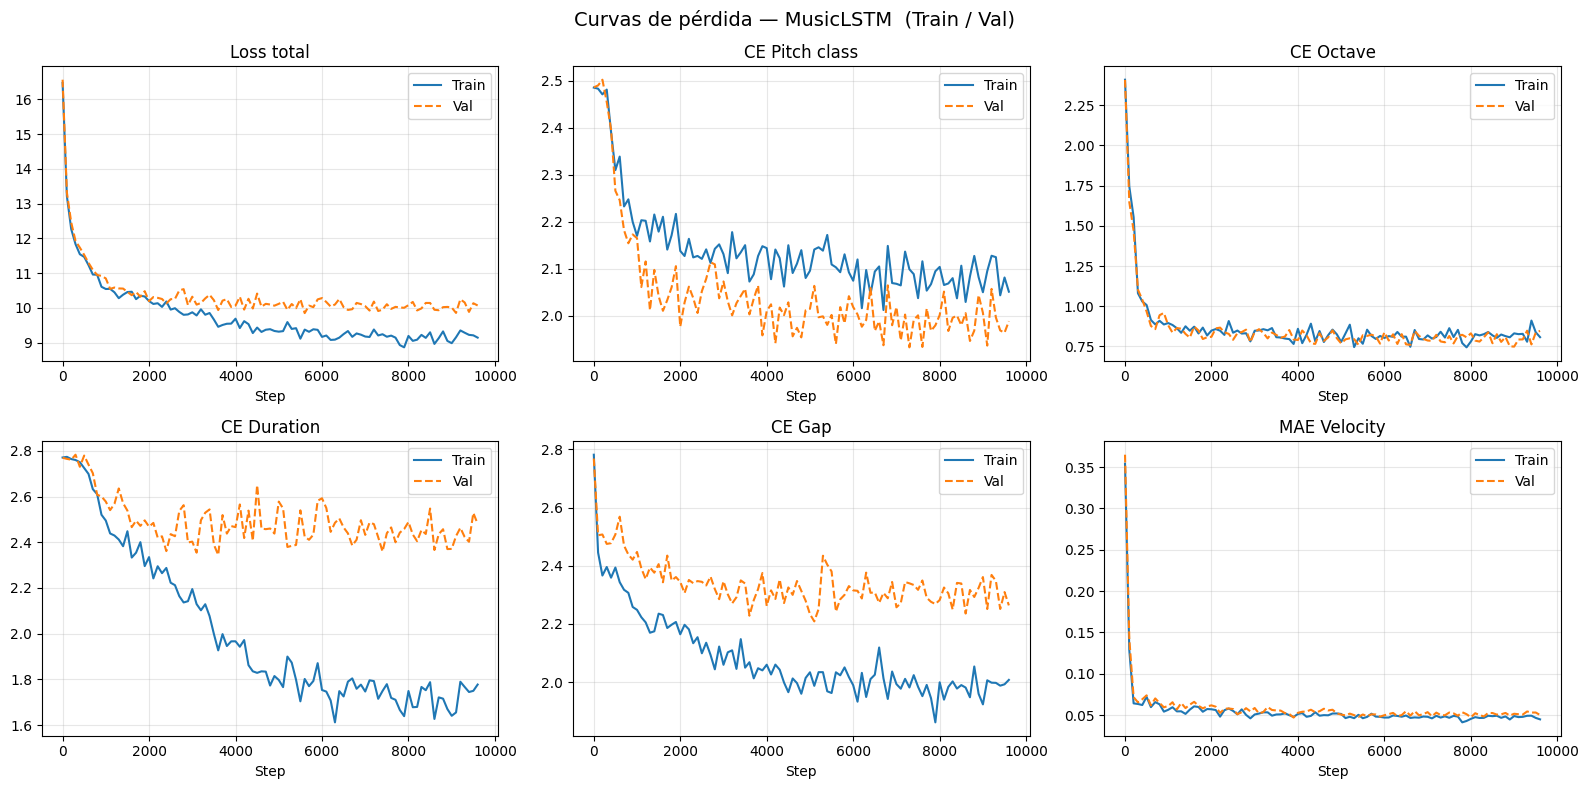

In [42]:
steps_logged = ([1] + list(range(100, MAX_STEPS, 100)) + [MAX_STEPS])[:len(log['train']['total'])]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Curvas de pérdida — MusicLSTM  (Train / Val)', fontsize=14)

componentes = [
    ('total',       'Loss total',     axes[0, 0]),
    ('pitch_class', 'CE Pitch class', axes[0, 1]),
    ('octave',      'CE Octave',      axes[0, 2]),
    ('duration',    'CE Duration',    axes[1, 0]),
    ('gap',         'CE Gap',         axes[1, 1]),
    ('velocity',    'MAE Velocity',   axes[1, 2]),
]
for key, title, ax in componentes:
    ax.plot(steps_logged, log['train'][key], label='Train')
    ax.plot(steps_logged, log['val'][key],   label='Val', linestyle='--')
    ax.set_title(title); ax.set_xlabel('Step'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Generación

In [43]:
@torch.no_grad()
def generate_notes(model, seed_seq, n_notes=200, temperature=1.0):
    """
    Genera n_notes notas desde un seed normalizado.
    Devuelve DataFrame [pitch, duration, gap, velocity] desnormalizado.
    """
    model.eval()
    context = torch.tensor(seed_seq[-BLOCK_SIZE:], dtype=torch.float32).unsqueeze(0).to(device)
    # Pitch de la última nota del seed para calcular el primer interval generado
    last_pc    = int(context[0, -1, 0].item())
    last_oct   = int(context[0, -1, 1].item())
    prev_pitch = 12 * last_oct + last_pc
    generated  = []

    for _ in range(n_notes):
        pc_logits, oct_logits, dur_logits, gap_logits, vel_pred = model(context)
        pc      = torch.multinomial(torch.softmax(pc_logits[0]  / temperature, -1), 1).item()
        oct_idx = torch.multinomial(torch.softmax(oct_logits[0] / temperature, -1), 1).item()
        dur_bin = torch.multinomial(torch.softmax(dur_logits[0] / temperature, -1), 1).item()
        gap_bin = torch.multinomial(torch.softmax(gap_logits[0] / temperature, -1), 1).item()
        dur     = float(dur_centers_norm[dur_bin])
        gap     = float(gap_centers_norm[gap_bin])
        vel     = vel_pred[0].item()
        pitch          = 12 * oct_idx + pc
        interval_norm  = float(np.clip((pitch - prev_pitch) / INTERVAL_CLIP, -1.0, 1.0))
        prev_pitch     = pitch
        generated.append([pc, oct_idx, dur, gap, vel, interval_norm])
        new_note = torch.tensor([[pc, oct_idx, dur, gap, vel, interval_norm]],
                                dtype=torch.float32).unsqueeze(0).to(device)
        context  = torch.cat([context[:, 1:, :], new_note], dim=1)

    gen           = np.array(generated)
    gen_denorm    = gen.copy()
    gen_denorm[:, 2:5] = scaler.inverse_transform(gen[:, 2:5])  # dur, gap, vel
    gen_denorm[:, 2] = np.expm1(gen_denorm[:, 2])  # undo log1p on duration
    pitch = np.clip(12 * gen[:, 1].astype(int) + gen[:, 0].astype(int), 0, 127)
    return pd.DataFrame({
        'pitch':    pitch,
        'duration': np.clip(gen_denorm[:, 2], 0.01, None),
        'gap':      gen_denorm[:, 3],
        'velocity': np.clip(gen_denorm[:, 4], 1, 127).astype(int),
    })


def denormalize_seed(seed_array):
    """Seed normalizado → DataFrame [pitch, duration, gap, velocity]."""
    arr = seed_array.copy()
    arr[:, 2:5] = scaler.inverse_transform(arr[:, 2:5])  # dur, gap, vel
    arr[:, 2] = np.expm1(arr[:, 2])  # undo log1p on duration
    pitch = np.clip(12 * arr[:, 1].astype(int) + arr[:, 0].astype(int), 0, 127)
    return pd.DataFrame({
        'pitch':    pitch,
        'duration': np.clip(arr[:, 2], 0.01, None),
        'gap':      arr[:, 3],
        'velocity': np.clip(arr[:, 4], 1, 127).astype(int),
    })


def notes_to_midi(df_notes, output_path, instrument_name='Acoustic Grand Piano'):
    """Escribe un DataFrame de notas como MIDI de un solo instrumento."""
    pm_out   = pretty_midi.PrettyMIDI()
    inst_out = pretty_midi.Instrument(pretty_midi.instrument_name_to_program(instrument_name))
    t = 0.0
    for _, row in df_notes.iterrows():
        t += max(float(row['duration']) + float(row['gap']), 0.0)
        inst_out.notes.append(pretty_midi.Note(
            velocity=int(row['velocity']), pitch=int(row['pitch']),
            start=t, end=t + float(row['duration'])
        ))
    pm_out.instruments.append(inst_out)
    pm_out.write(output_path)


def two_hands_to_midi(df_hand1, df_hand2, output_path,
                      instrument_name='Acoustic Grand Piano'):
    """Escribe dos manos como dos instrumentos en un único MIDI."""
    pm_out  = pretty_midi.PrettyMIDI()
    program = pretty_midi.instrument_name_to_program(instrument_name)
    for hand_df in [df_hand1, df_hand2]:
        inst = pretty_midi.Instrument(program=program)
        t = 0.0
        for _, row in hand_df.iterrows():
            t += max(float(row['duration']) + float(row['gap']), 0.0)
            inst.notes.append(pretty_midi.Note(
                velocity=int(row['velocity']), pitch=int(row['pitch']),
                start=t, end=t + float(row['duration'])
            ))
        pm_out.instruments.append(inst)
    pm_out.write(output_path)


In [44]:
if COLAB:
    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = './generated'
os.makedirs(GENERATED_DIR, exist_ok=True)

# ── Elegir canción del test para visualizar ──────────────────────────────────
# Preferimos una con 2 manos; si ninguna tiene 2, usamos la primera.
gen_song_key = next(
    (k for k in test_song_keys if len(song_groups[k]) >= 2),
    test_song_keys[0]
)
n_hands = min(len(song_groups[gen_song_key]), 2)
print(f'Canción para generación: {gen_song_key}  ({n_hands} mano(s))')

# Índices de las manos de esta canción dentro de test_seqs / test_arrays
hand_test_idx = [test_names.index(n) for n in song_group_names[gen_song_key][:n_hands]]

TEMPERATURE = 0.7
N_GEN       = 200

hand_seeds_norm = [test_arrays[i][:BLOCK_SIZE]  for i in hand_test_idx]
hand_seeds_df   = [denormalize_seed(s)          for s in hand_seeds_norm]
hand_real_df    = [test_seqs[i].reset_index(drop=True) for i in hand_test_idx]
hand_gen_df     = [generate_notes(model, s, n_notes=N_GEN, temperature=TEMPERATURE)
                   for s in hand_seeds_norm]

# ── Guardar MIDIs ────────────────────────────────────────────────────────────
for h in range(n_hands):
    df_full = pd.concat([hand_seeds_df[h], hand_gen_df[h]], ignore_index=True)
    path    = os.path.join(GENERATED_DIR, f'beethoven_bs{BLOCK_SIZE}_hand{h+1}.mid')
    notes_to_midi(df_full, path)
    print(f'Guardado: {os.path.basename(path)}')

if n_hands >= 2:
    df_full1 = pd.concat([hand_seeds_df[0], hand_gen_df[0]], ignore_index=True)
    df_full2 = pd.concat([hand_seeds_df[1], hand_gen_df[1]], ignore_index=True)
    path_comb = os.path.join(GENERATED_DIR, f'beethoven_bs{BLOCK_SIZE}_combined.mid')
    two_hands_to_midi(df_full1, df_full2, path_comb)
    print(f'Guardado: {os.path.basename(path_comb)}')
else:
    print('Solo 1 mano disponible; MIDI combinado no generado.')

print(f'\nMIDIs en: {GENERATED_DIR}')

if COLAB:
    from google.colab import files
    for h in range(n_hands):
        files.download(os.path.join(GENERATED_DIR, f'beethoven_bs{BLOCK_SIZE}_hand{h+1}.mid'))
    if n_hands >= 2:
        files.download(os.path.join(GENERATED_DIR, f'beethoven_bs{BLOCK_SIZE}_combined.mid'))


Canción para generación: beethoven_opus90_2.mid  (2 mano(s))
Guardado: beethoven_bs100_hand1.mid
Guardado: beethoven_bs100_hand2.mid
Guardado: beethoven_bs100_combined.mid

MIDIs en: /content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Evaluación: generado vs real

In [45]:
# ── Preparar DataFrames con columna 'step' para la visualización ─────────────
def add_step(df):
    """Añade columna step = duration + gap (tiempo entre inicios consecutivos)."""
    d = df.copy()
    d['step'] = d['duration'] + d['gap']
    return d

# Seed, real ref y generado para cada mano
eval_data = []
for h in range(n_hands):
    seed_df = add_step(hand_seeds_df[h])
    real_df = add_step(hand_real_df[h].iloc[BLOCK_SIZE : BLOCK_SIZE + N_GEN].reset_index(drop=True))
    gen_df  = add_step(hand_gen_df[h])
    eval_data.append({'seed': seed_df, 'real': real_df, 'gen': gen_df})

# ── Estadísticas comparativas ─────────────────────────────────────────────────
for h, ed in enumerate(eval_data):
    print(f'── Mano {h+1} ──')
    stats = pd.DataFrame({
        'pitch_mean':    [ed['gen']['pitch'].mean(),    ed['real']['pitch'].mean()],
        'pitch_std':     [ed['gen']['pitch'].std(),     ed['real']['pitch'].std()],
        'step_mean':     [ed['gen']['step'].mean(),     ed['real']['step'].mean()],
        'duration_mean': [ed['gen']['duration'].mean(), ed['real']['duration'].mean()],
        'velocity_mean': [ed['gen']['velocity'].mean(), ed['real']['velocity'].mean()],
    }, index=['Generado', 'Real']).T.round(4)
    print(stats, '\n')


── Mano 1 ──
               Generado     Real
pitch_mean      75.0800  72.4150
pitch_std        8.8977   7.7714
step_mean        0.1278   0.2725
duration_mean    0.2864   0.5237
velocity_mean   47.7950  51.0350 

── Mano 2 ──
               Generado     Real
pitch_mean      57.9950  53.8750
pitch_std        7.3727   8.0150
step_mean        0.2185   0.2339
duration_mean    0.4140   0.2448
velocity_mean   38.3800  38.8300 



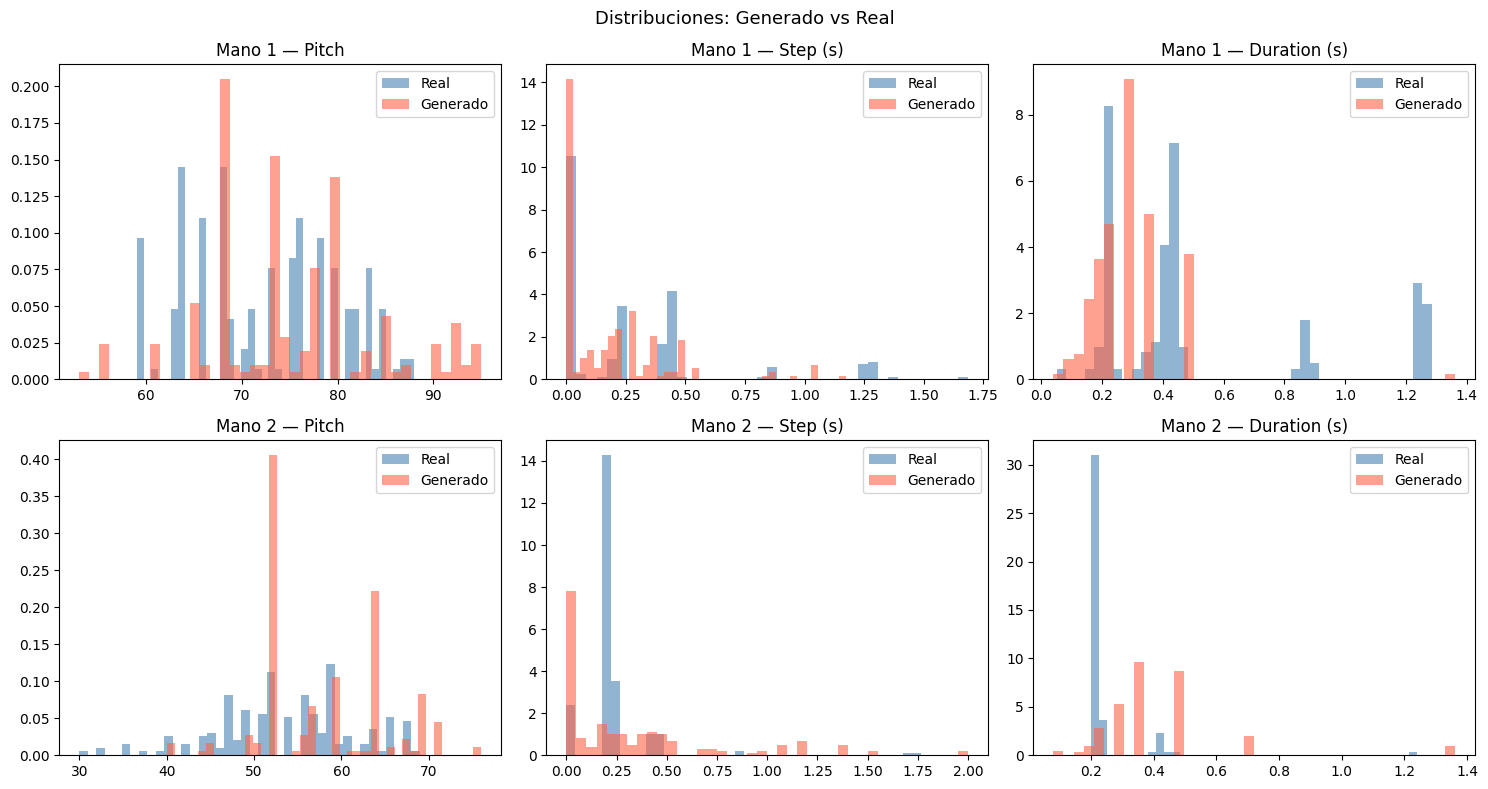

In [46]:
fig, axes = plt.subplots(n_hands, 3, figsize=(15, 4 * n_hands), squeeze=False)
fig.suptitle('Distribuciones: Generado vs Real', fontsize=13)

for h, ed in enumerate(eval_data):
    for ax, col, label, clip_val in [
        (axes[h, 0], 'pitch',    f'Mano {h+1} — Pitch',        None),
        (axes[h, 1], 'step',     f'Mano {h+1} — Step (s)',     2.0),
        (axes[h, 2], 'duration', f'Mano {h+1} — Duration (s)', 2.0),
    ]:
        gv = ed['gen']['gen' if 'gen' in ed['gen'] else col].clip(0, clip_val) if clip_val else ed['gen'][col]
        gv = ed['gen'][col].clip(0, clip_val) if clip_val else ed['gen'][col]
        rv = ed['real'][col].clip(0, clip_val) if clip_val else ed['real'][col]
        ax.hist(rv, bins=40, alpha=0.6, label='Real',     density=True, color='steelblue')
        ax.hist(gv, bins=40, alpha=0.6, label='Generado', density=True, color='tomato')
        ax.set_title(label); ax.legend()

plt.tight_layout(); plt.show()


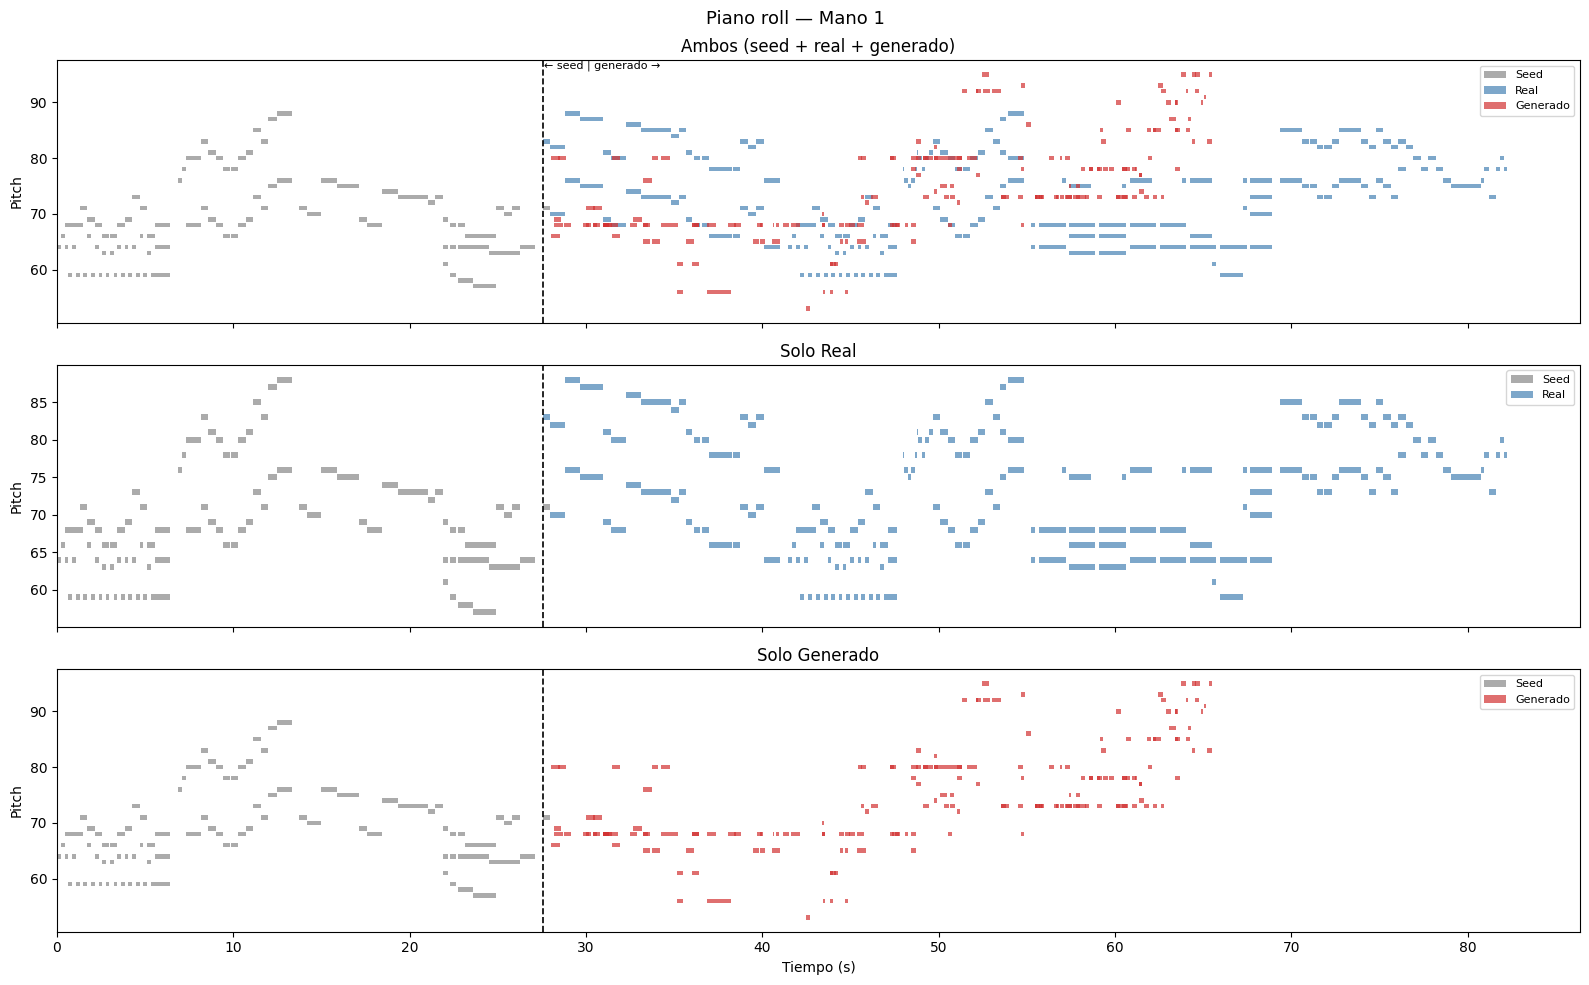

In [47]:
# ── Función auxiliar para piano roll en Matplotlib ─────────────────────────
def piano_roll_bars(ax, df, color, label, offset_t=0.0, alpha=0.7):
    """
    Dibuja notas como barras horizontales (barh) en un eje matplotlib.
    Devuelve t_final (tiempo tras el último step).
    """
    t = offset_t
    for _, row in df.iterrows():
        t += max(float(row['duration']) + float(row['gap']), 0.0)
        ax.barh(float(row['pitch']), float(row['duration']),
                left=t, height=0.8, color=color, alpha=alpha,
                label=label)
        label = '_nolegend_'   # solo una entrada en la leyenda por serie
    return t


# ── Gráfica 1: Mano 1 ────────────────────────────────────────────────────────
ed = eval_data[0]

fig1, axes1 = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig1.suptitle('Piano roll — Mano 1', fontsize=13)

se1 = piano_roll_bars(axes1[0], ed['seed'], '#888888', 'Seed')
piano_roll_bars(axes1[0], ed['real'], '#4682B4', 'Real', offset_t=se1)
piano_roll_bars(axes1[0], ed['gen'],  '#D23232', 'Generado', offset_t=se1)
axes1[0].axvline(se1, color='black', ls='--', lw=1.2)
axes1[0].text(se1 + 0.1, axes1[0].get_ylim()[1] if axes1[0].get_ylim()[1] != 1.0 else 80,
              '← seed | generado →', fontsize=8, va='top')
axes1[0].set_title('Ambos (seed + real + generado)')
axes1[0].set_ylabel('Pitch'); axes1[0].legend(loc='upper right', fontsize=8)

se1b = piano_roll_bars(axes1[1], ed['seed'], '#888888', 'Seed')
piano_roll_bars(axes1[1], ed['real'], '#4682B4', 'Real', offset_t=se1b)
axes1[1].axvline(se1b, color='black', ls='--', lw=1.2)
axes1[1].set_title('Solo Real')
axes1[1].set_ylabel('Pitch'); axes1[1].legend(loc='upper right', fontsize=8)

se1c = piano_roll_bars(axes1[2], ed['seed'], '#888888', 'Seed')
piano_roll_bars(axes1[2], ed['gen'], '#D23232', 'Generado', offset_t=se1c)
axes1[2].axvline(se1c, color='black', ls='--', lw=1.2)
axes1[2].set_title('Solo Generado')
axes1[2].set_ylabel('Pitch'); axes1[2].set_xlabel('Tiempo (s)')
axes1[2].legend(loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()


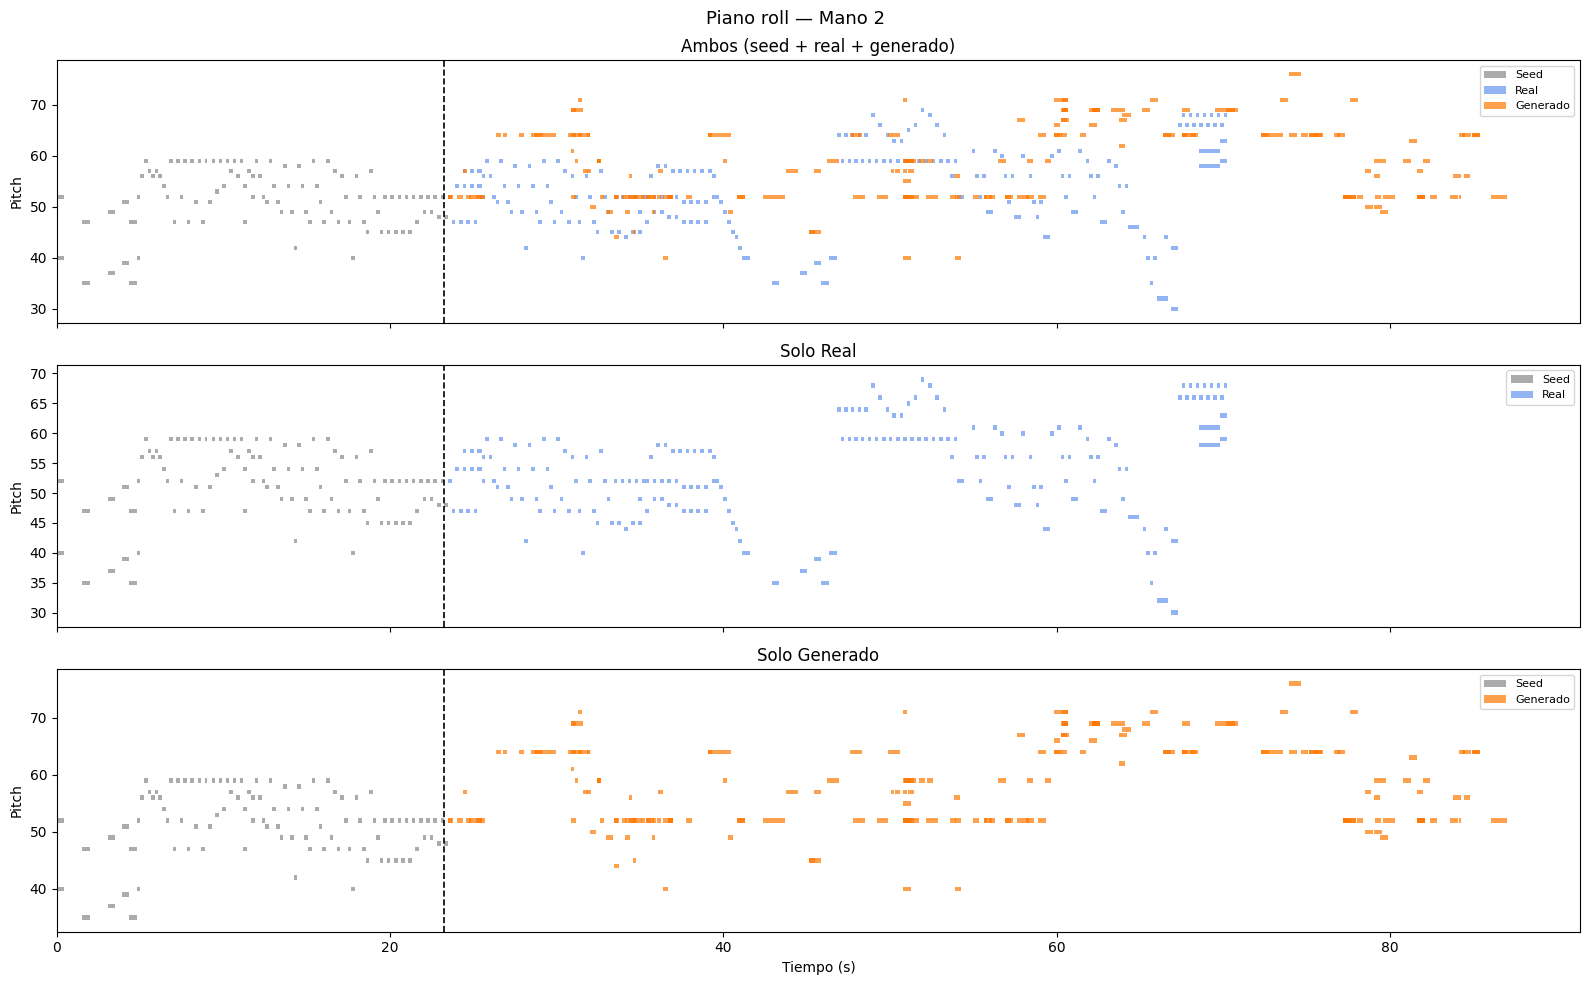

In [48]:
# ── Gráfica 2: Mano 2 ────────────────────────────────────────────────────────
if n_hands >= 2:
    ed2 = eval_data[1]

    fig2, axes2 = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    fig2.suptitle('Piano roll — Mano 2', fontsize=13)

    se2 = piano_roll_bars(axes2[0], ed2['seed'], '#888888', 'Seed')
    piano_roll_bars(axes2[0], ed2['real'], '#6495ED', 'Real',     offset_t=se2)
    piano_roll_bars(axes2[0], ed2['gen'],  '#FF7800', 'Generado', offset_t=se2)
    axes2[0].axvline(se2, color='black', ls='--', lw=1.2)
    axes2[0].set_title('Ambos (seed + real + generado)')
    axes2[0].set_ylabel('Pitch'); axes2[0].legend(loc='upper right', fontsize=8)

    se2b = piano_roll_bars(axes2[1], ed2['seed'], '#888888', 'Seed')
    piano_roll_bars(axes2[1], ed2['real'], '#6495ED', 'Real', offset_t=se2b)
    axes2[1].axvline(se2b, color='black', ls='--', lw=1.2)
    axes2[1].set_title('Solo Real')
    axes2[1].set_ylabel('Pitch'); axes2[1].legend(loc='upper right', fontsize=8)

    se2c = piano_roll_bars(axes2[2], ed2['seed'], '#888888', 'Seed')
    piano_roll_bars(axes2[2], ed2['gen'], '#FF7800', 'Generado', offset_t=se2c)
    axes2[2].axvline(se2c, color='black', ls='--', lw=1.2)
    axes2[2].set_title('Solo Generado')
    axes2[2].set_ylabel('Pitch'); axes2[2].set_xlabel('Tiempo (s)')
    axes2[2].legend(loc='upper right', fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print('Solo 1 mano disponible; gráfica de mano 2 omitida.')


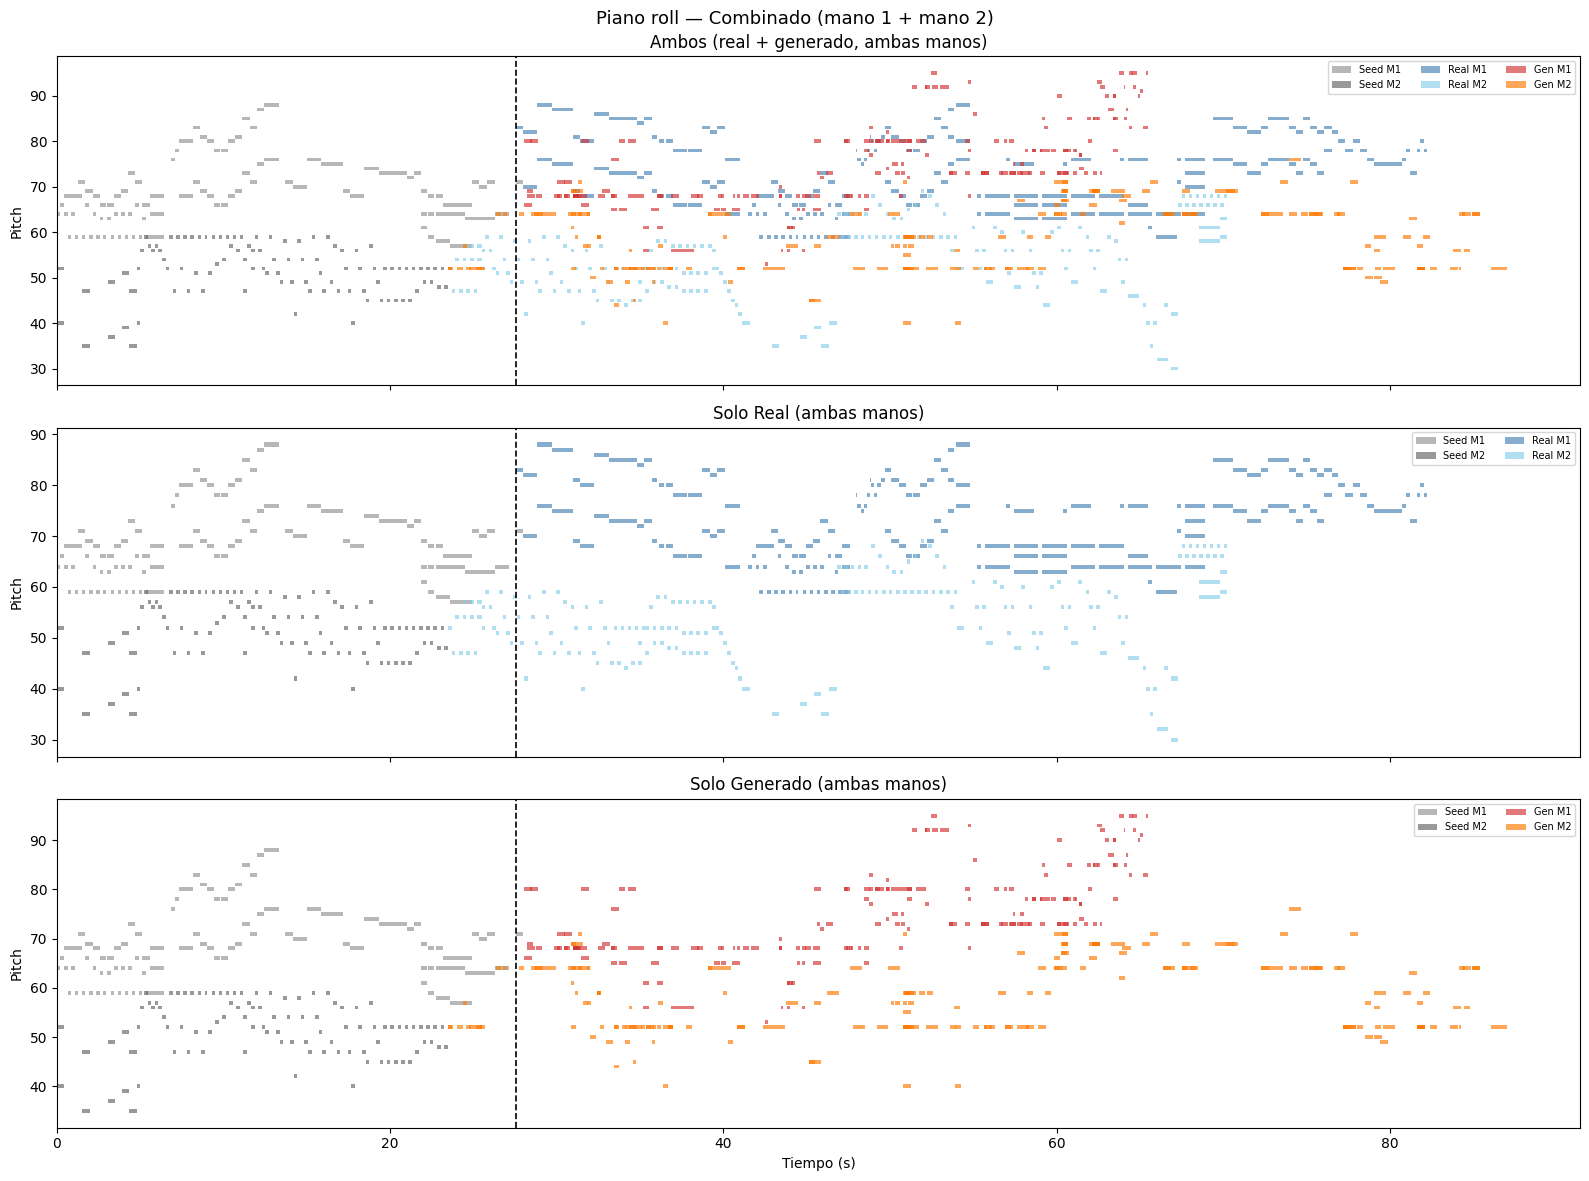

In [49]:
# ── Gráfica 3: Combinada (ambas manos) ──────────────────────────────────────
if n_hands >= 2:
    ed1, ed2 = eval_data[0], eval_data[1]

    fig3, axes3 = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig3.suptitle('Piano roll — Combinado (mano 1 + mano 2)', fontsize=13)

    # Ambas manos: seed + real + generado
    se_c1 = piano_roll_bars(axes3[0], ed1['seed'], '#888888', 'Seed M1', alpha=0.6)
    se_c2 = piano_roll_bars(axes3[0], ed2['seed'], '#555555', 'Seed M2', alpha=0.6)
    piano_roll_bars(axes3[0], ed1['real'], '#4682B4', 'Real M1',     offset_t=se_c1, alpha=0.65)
    piano_roll_bars(axes3[0], ed2['real'], '#87CEEB', 'Real M2',     offset_t=se_c2, alpha=0.65)
    piano_roll_bars(axes3[0], ed1['gen'],  '#D23232', 'Gen M1',      offset_t=se_c1, alpha=0.65)
    piano_roll_bars(axes3[0], ed2['gen'],  '#FF7800', 'Gen M2',      offset_t=se_c2, alpha=0.65)
    axes3[0].axvline(max(se_c1, se_c2), color='black', ls='--', lw=1.2)
    axes3[0].set_title('Ambos (real + generado, ambas manos)')
    axes3[0].set_ylabel('Pitch')
    axes3[0].legend(loc='upper right', fontsize=7, ncol=3)

    # Solo real: ambas manos
    sr1 = piano_roll_bars(axes3[1], ed1['seed'], '#888888', 'Seed M1', alpha=0.6)
    sr2 = piano_roll_bars(axes3[1], ed2['seed'], '#555555', 'Seed M2', alpha=0.6)
    piano_roll_bars(axes3[1], ed1['real'], '#4682B4', 'Real M1', offset_t=sr1, alpha=0.65)
    piano_roll_bars(axes3[1], ed2['real'], '#87CEEB', 'Real M2', offset_t=sr2, alpha=0.65)
    axes3[1].axvline(max(sr1, sr2), color='black', ls='--', lw=1.2)
    axes3[1].set_title('Solo Real (ambas manos)')
    axes3[1].set_ylabel('Pitch')
    axes3[1].legend(loc='upper right', fontsize=7, ncol=2)

    # Solo generado: ambas manos
    sg1 = piano_roll_bars(axes3[2], ed1['seed'], '#888888', 'Seed M1', alpha=0.6)
    sg2 = piano_roll_bars(axes3[2], ed2['seed'], '#555555', 'Seed M2', alpha=0.6)
    piano_roll_bars(axes3[2], ed1['gen'], '#D23232', 'Gen M1', offset_t=sg1, alpha=0.65)
    piano_roll_bars(axes3[2], ed2['gen'], '#FF7800', 'Gen M2', offset_t=sg2, alpha=0.65)
    axes3[2].axvline(max(sg1, sg2), color='black', ls='--', lw=1.2)
    axes3[2].set_title('Solo Generado (ambas manos)')
    axes3[2].set_ylabel('Pitch'); axes3[2].set_xlabel('Tiempo (s)')
    axes3[2].legend(loc='upper right', fontsize=7, ncol=2)

    plt.tight_layout(); plt.show()
else:
    print('Solo 1 mano disponible; gráfica combinada omitida.')


## 8. Generación con Top-K (K=5 en pitch)

Igual que la sección anterior, pero con **muestreo Top-K** para `pitch_class` y `octave`:
solo se consideran las 5 clases más probables antes de samplear.
El resto de features (duration, gap, velocity) mantienen el muestreo con temperatura.

In [50]:
def top_k_sample(logits, temperature, k):
    """Filtra a los top-k logits y samplea de su distribución normalizada."""
    logits = logits / temperature
    threshold = torch.topk(logits, k).values[-1]
    logits    = logits.masked_fill(logits < threshold, float('-inf'))
    return torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1).item()


@torch.no_grad()
def generate_notes_topk(model, seed_seq, n_notes=200, temperature=1.0, top_k=5):
    """
    Igual que generate_notes pero usa Top-K (k=top_k) para pitch_class y octave.
    duration, gap y velocity mantienen muestreo estándar con temperatura.
    """
    model.eval()
    context = torch.tensor(seed_seq[-BLOCK_SIZE:], dtype=torch.float32).unsqueeze(0).to(device)
    last_pc    = int(context[0, -1, 0].item())
    last_oct   = int(context[0, -1, 1].item())
    prev_pitch = 12 * last_oct + last_pc
    generated  = []

    for _ in range(n_notes):
        pc_logits, oct_logits, dur_logits, gap_logits, vel_pred = model(context)

        pc      = top_k_sample(pc_logits[0],  temperature, top_k)
        oct_idx = top_k_sample(oct_logits[0], temperature, top_k)
        dur_bin = torch.multinomial(torch.softmax(dur_logits[0] / temperature, -1), 1).item()
        gap_bin = torch.multinomial(torch.softmax(gap_logits[0] / temperature, -1), 1).item()
        dur     = float(dur_centers_norm[dur_bin])
        gap     = float(gap_centers_norm[gap_bin])
        vel     = vel_pred[0].item()

        pitch         = 12 * oct_idx + pc
        interval_norm = float(np.clip((pitch - prev_pitch) / INTERVAL_CLIP, -1.0, 1.0))
        prev_pitch    = pitch

        generated.append([pc, oct_idx, dur, gap, vel, interval_norm])
        new_note = torch.tensor([[pc, oct_idx, dur, gap, vel, interval_norm]],
                                dtype=torch.float32).unsqueeze(0).to(device)
        context  = torch.cat([context[:, 1:, :], new_note], dim=1)

    gen           = np.array(generated)
    gen_denorm    = gen.copy()
    gen_denorm[:, 2:5] = scaler.inverse_transform(gen[:, 2:5])
    gen_denorm[:, 2] = np.expm1(gen_denorm[:, 2])  # undo log1p on duration
    pitch = np.clip(12 * gen[:, 1].astype(int) + gen[:, 0].astype(int), 0, 127)
    return pd.DataFrame({
        'pitch':    pitch,
        'duration': np.clip(gen_denorm[:, 2], 0.01, None),
        'gap':      gen_denorm[:, 3],
        'velocity': np.clip(gen_denorm[:, 4], 1, 127).astype(int),
    })


In [51]:
TOP_K       = 5
TEMPERATURE = 0.7

hand_gen_topk_df = [generate_notes_topk(model, s, n_notes=N_GEN,
                                        temperature=TEMPERATURE, top_k=TOP_K)
                   for s in hand_seeds_norm]

for h in range(n_hands):
    df_full = pd.concat([hand_seeds_df[h], hand_gen_topk_df[h]], ignore_index=True)
    path    = os.path.join(GENERATED_DIR, f'beethoven_topk_bs{BLOCK_SIZE}_hand{h+1}.mid')
    notes_to_midi(df_full, path)
    print(f'Guardado: {os.path.basename(path)}')

if n_hands >= 2:
    df_full1 = pd.concat([hand_seeds_df[0], hand_gen_topk_df[0]], ignore_index=True)
    df_full2 = pd.concat([hand_seeds_df[1], hand_gen_topk_df[1]], ignore_index=True)
    path_comb = os.path.join(GENERATED_DIR, f'beethoven_topk_bs{BLOCK_SIZE}_combined.mid')
    two_hands_to_midi(df_full1, df_full2, path_comb)
    print(f'Guardado: {os.path.basename(path_comb)}')

if COLAB:
    from google.colab import files
    for h in range(n_hands):
        files.download(os.path.join(GENERATED_DIR, f'beethoven_topk_bs{BLOCK_SIZE}_hand{h+1}.mid'))
    if n_hands >= 2:
        files.download(os.path.join(GENERATED_DIR, f'beethoven_topk_bs{BLOCK_SIZE}_combined.mid'))


Guardado: beethoven_topk_bs100_hand1.mid
Guardado: beethoven_topk_bs100_hand2.mid
Guardado: beethoven_topk_bs100_combined.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Evaluación Top-K

In [52]:
eval_data_topk = []
for h in range(n_hands):
    seed_df = add_step(hand_seeds_df[h])
    real_df = add_step(hand_real_df[h].iloc[BLOCK_SIZE : BLOCK_SIZE + N_GEN].reset_index(drop=True))
    gen_df  = add_step(hand_gen_topk_df[h])
    eval_data_topk.append({'seed': seed_df, 'real': real_df, 'gen': gen_df})

for h, ed in enumerate(eval_data_topk):
    print(f'── Mano {h+1} (Top-K={TOP_K}) ──')
    stats = pd.DataFrame({
        'pitch_mean':    [ed['gen']['pitch'].mean(),    ed['real']['pitch'].mean()],
        'pitch_std':     [ed['gen']['pitch'].std(),     ed['real']['pitch'].std()],
        'step_mean':     [ed['gen']['step'].mean(),     ed['real']['step'].mean()],
        'duration_mean': [ed['gen']['duration'].mean(), ed['real']['duration'].mean()],
        'velocity_mean': [ed['gen']['velocity'].mean(), ed['real']['velocity'].mean()],
    }, index=['Generado TopK', 'Real']).T.round(4)
    print(stats, '\n')


── Mano 1 (Top-K=5) ──
               Generado TopK     Real
pitch_mean           67.2850  72.4150
pitch_std             6.2151   7.7714
step_mean             0.1739   0.2725
duration_mean         0.4419   0.5237
velocity_mean        44.9500  51.0350 

── Mano 2 (Top-K=5) ──
               Generado TopK     Real
pitch_mean           61.4900  53.8750
pitch_std            11.3633   8.0150
step_mean             0.1397   0.2339
duration_mean         0.2716   0.2448
velocity_mean        40.3500  38.8300 



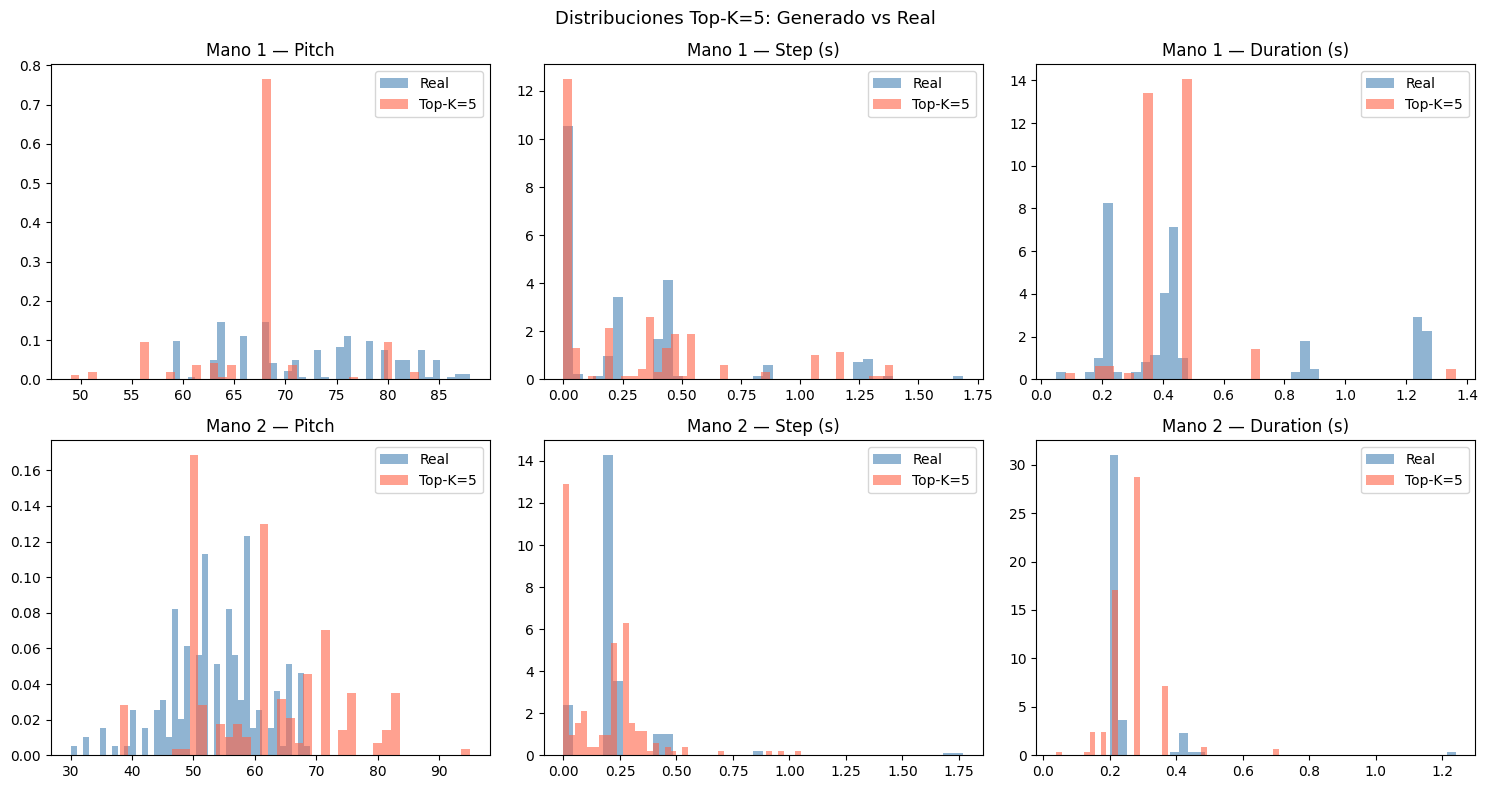

In [53]:
fig, axes = plt.subplots(n_hands, 3, figsize=(15, 4 * n_hands), squeeze=False)
fig.suptitle(f'Distribuciones Top-K={TOP_K}: Generado vs Real', fontsize=13)

for h, ed in enumerate(eval_data_topk):
    for ax, col, label, clip_val in [
        (axes[h, 0], 'pitch',    f'Mano {h+1} — Pitch',        None),
        (axes[h, 1], 'step',     f'Mano {h+1} — Step (s)',     2.0),
        (axes[h, 2], 'duration', f'Mano {h+1} — Duration (s)', 2.0),
    ]:
        gv = ed['gen'][col].clip(0, clip_val)  if clip_val else ed['gen'][col]
        rv = ed['real'][col].clip(0, clip_val) if clip_val else ed['real'][col]
        ax.hist(rv, bins=40, alpha=0.6, label='Real',          density=True, color='steelblue')
        ax.hist(gv, bins=40, alpha=0.6, label=f'Top-K={TOP_K}', density=True, color='tomato')
        ax.set_title(label); ax.legend()

plt.tight_layout(); plt.show()


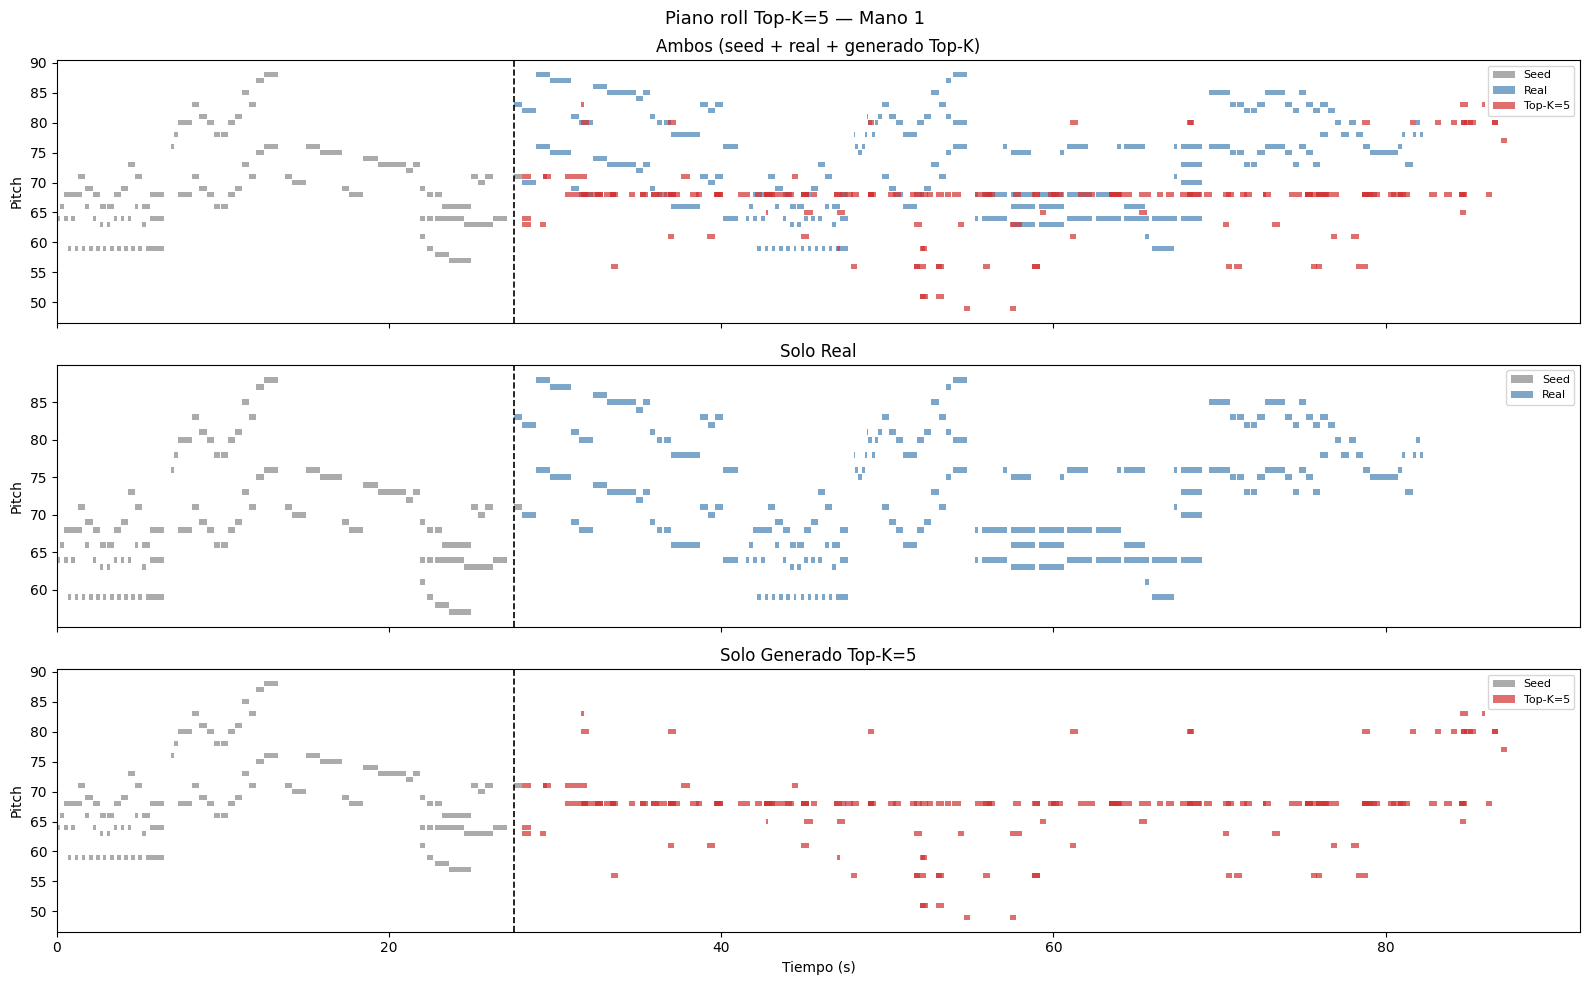

In [54]:
ed = eval_data_topk[0]

fig1, axes1 = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig1.suptitle(f'Piano roll Top-K={TOP_K} — Mano 1', fontsize=13)

se1 = piano_roll_bars(axes1[0], ed['seed'], '#888888', 'Seed')
piano_roll_bars(axes1[0], ed['real'], '#4682B4', 'Real',     offset_t=se1)
piano_roll_bars(axes1[0], ed['gen'],  '#D23232', f'Top-K={TOP_K}', offset_t=se1)
axes1[0].axvline(se1, color='black', ls='--', lw=1.2)
axes1[0].set_title('Ambos (seed + real + generado Top-K)')
axes1[0].set_ylabel('Pitch'); axes1[0].legend(loc='upper right', fontsize=8)

se1b = piano_roll_bars(axes1[1], ed['seed'], '#888888', 'Seed')
piano_roll_bars(axes1[1], ed['real'], '#4682B4', 'Real', offset_t=se1b)
axes1[1].axvline(se1b, color='black', ls='--', lw=1.2)
axes1[1].set_title('Solo Real')
axes1[1].set_ylabel('Pitch'); axes1[1].legend(loc='upper right', fontsize=8)

se1c = piano_roll_bars(axes1[2], ed['seed'], '#888888', 'Seed')
piano_roll_bars(axes1[2], ed['gen'], '#D23232', f'Top-K={TOP_K}', offset_t=se1c)
axes1[2].axvline(se1c, color='black', ls='--', lw=1.2)
axes1[2].set_title(f'Solo Generado Top-K={TOP_K}')
axes1[2].set_ylabel('Pitch'); axes1[2].set_xlabel('Tiempo (s)')
axes1[2].legend(loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()


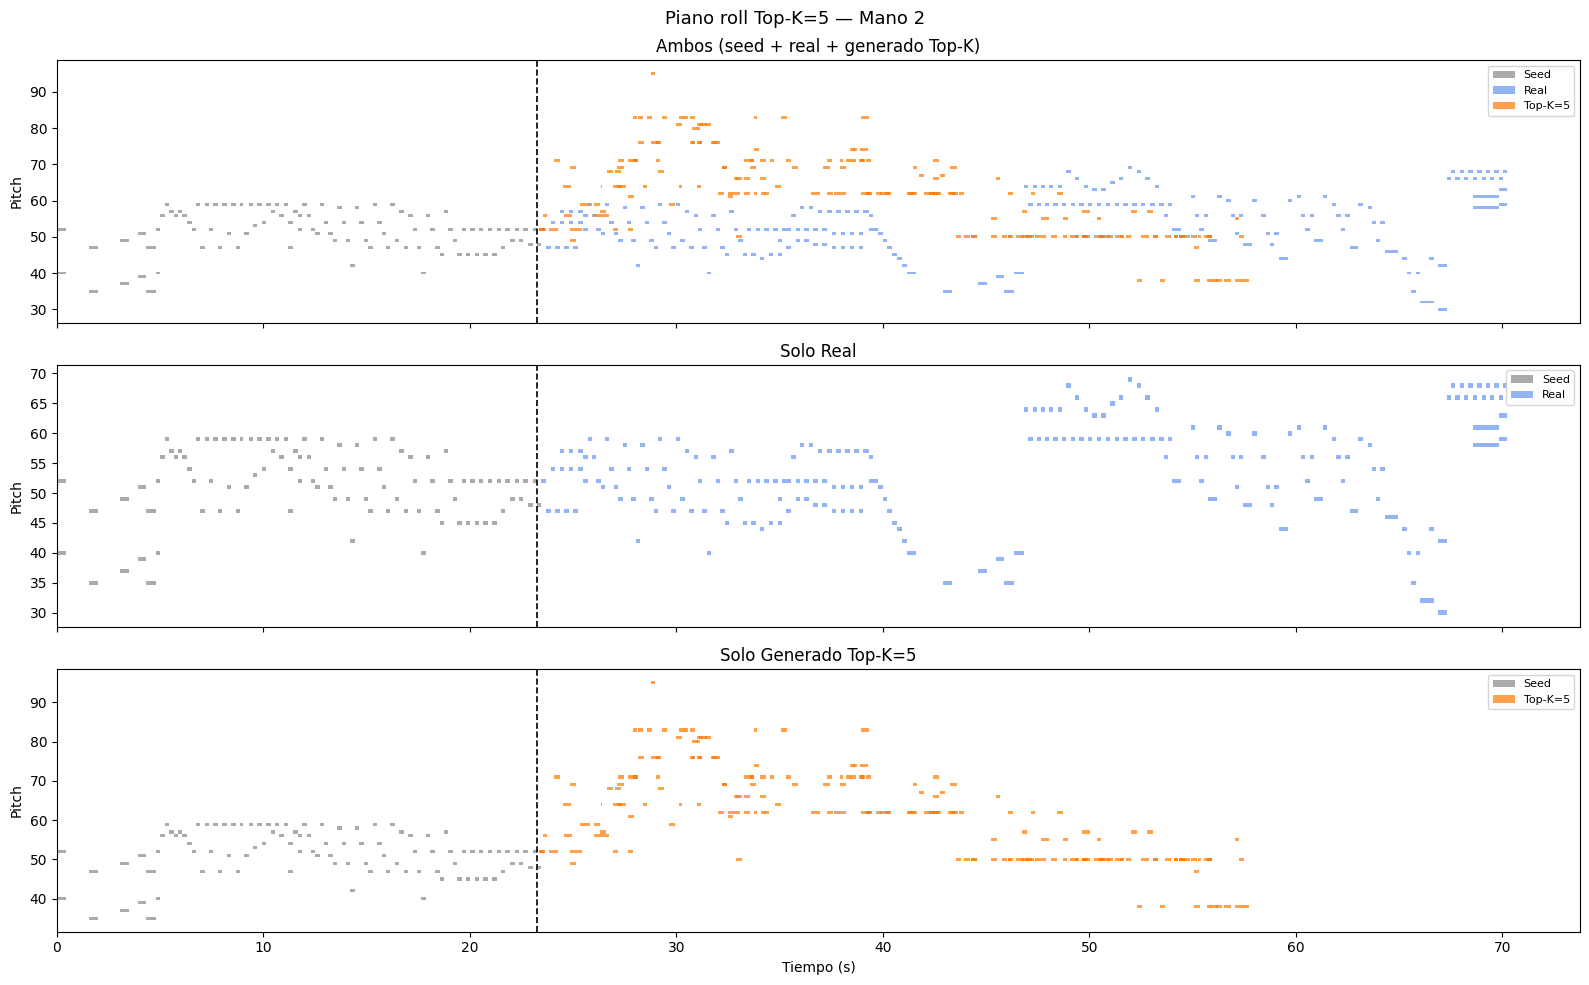

In [55]:
if n_hands >= 2:
    ed2 = eval_data_topk[1]

    fig2, axes2 = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    fig2.suptitle(f'Piano roll Top-K={TOP_K} — Mano 2', fontsize=13)

    se2 = piano_roll_bars(axes2[0], ed2['seed'], '#888888', 'Seed')
    piano_roll_bars(axes2[0], ed2['real'], '#6495ED', 'Real',          offset_t=se2)
    piano_roll_bars(axes2[0], ed2['gen'],  '#FF7800', f'Top-K={TOP_K}', offset_t=se2)
    axes2[0].axvline(se2, color='black', ls='--', lw=1.2)
    axes2[0].set_title('Ambos (seed + real + generado Top-K)')
    axes2[0].set_ylabel('Pitch'); axes2[0].legend(loc='upper right', fontsize=8)

    se2b = piano_roll_bars(axes2[1], ed2['seed'], '#888888', 'Seed')
    piano_roll_bars(axes2[1], ed2['real'], '#6495ED', 'Real', offset_t=se2b)
    axes2[1].axvline(se2b, color='black', ls='--', lw=1.2)
    axes2[1].set_title('Solo Real')
    axes2[1].set_ylabel('Pitch'); axes2[1].legend(loc='upper right', fontsize=8)

    se2c = piano_roll_bars(axes2[2], ed2['seed'], '#888888', 'Seed')
    piano_roll_bars(axes2[2], ed2['gen'], '#FF7800', f'Top-K={TOP_K}', offset_t=se2c)
    axes2[2].axvline(se2c, color='black', ls='--', lw=1.2)
    axes2[2].set_title(f'Solo Generado Top-K={TOP_K}')
    axes2[2].set_ylabel('Pitch'); axes2[2].set_xlabel('Tiempo (s)')
    axes2[2].legend(loc='upper right', fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print('Solo 1 mano disponible; gráfica de mano 2 omitida.')


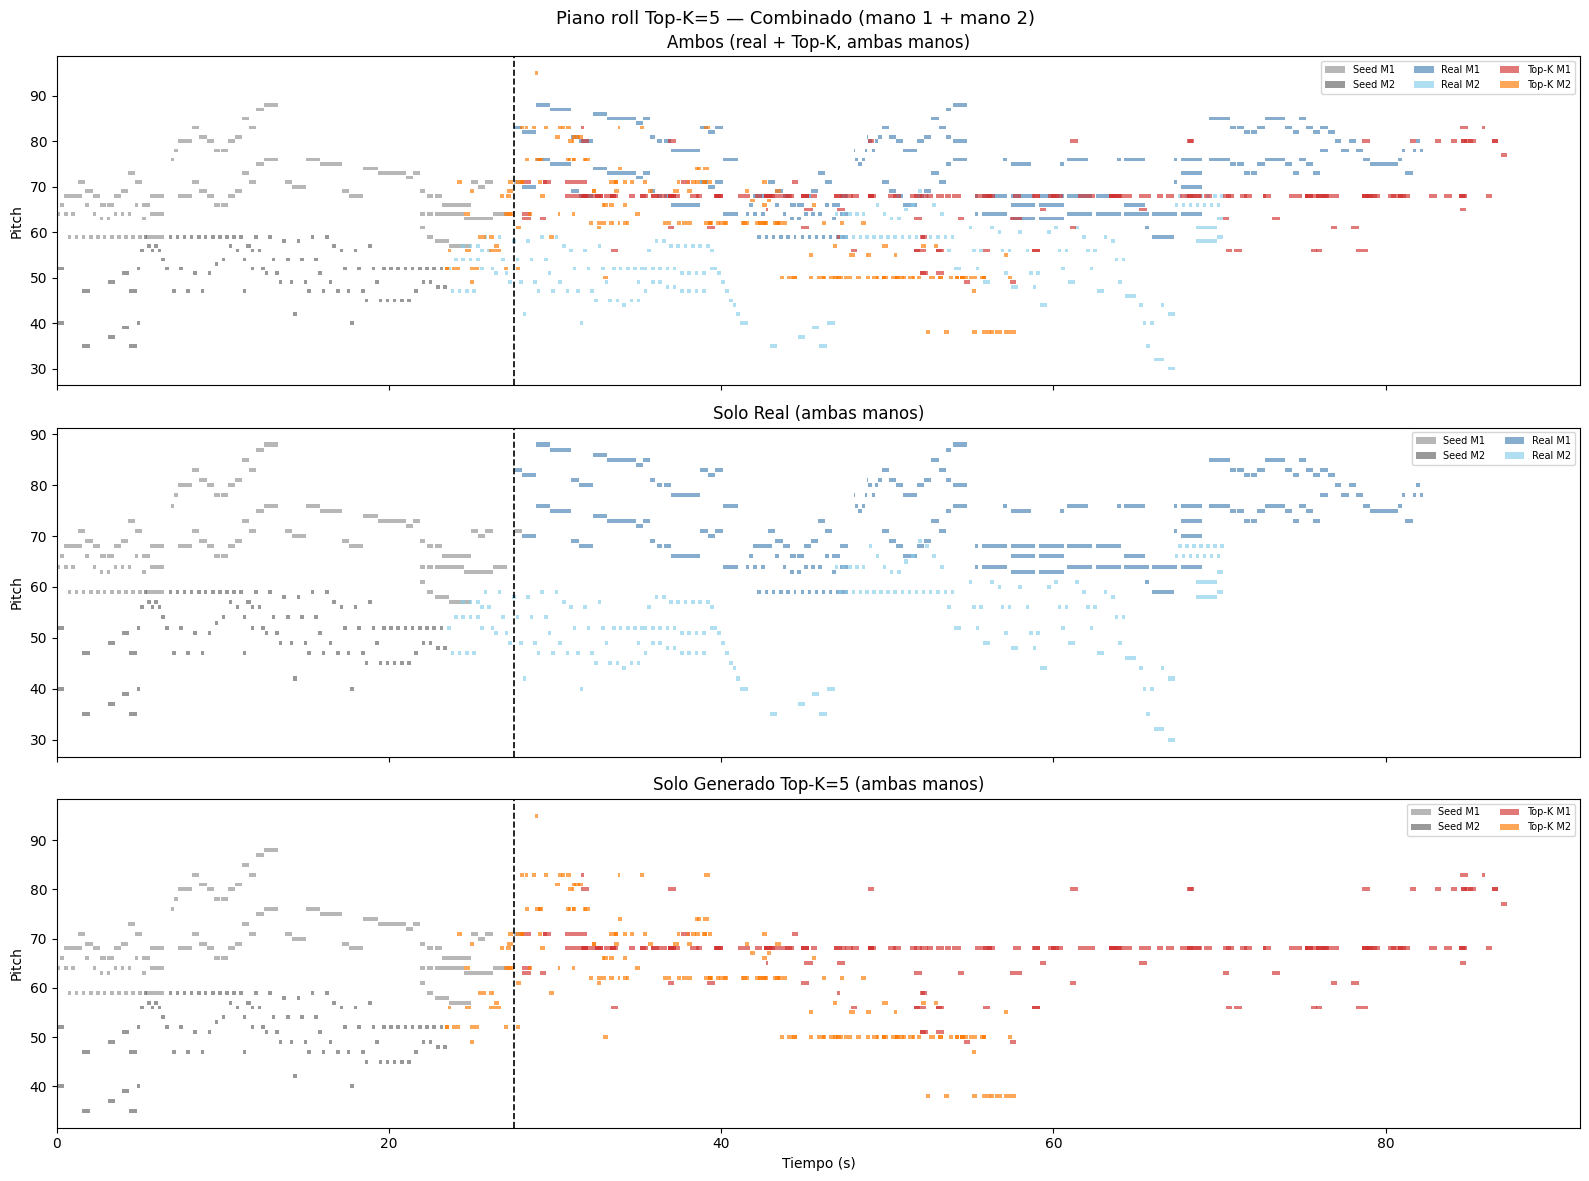

In [56]:
if n_hands >= 2:
    ed1, ed2 = eval_data_topk[0], eval_data_topk[1]

    fig3, axes3 = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig3.suptitle(f'Piano roll Top-K={TOP_K} — Combinado (mano 1 + mano 2)', fontsize=13)

    se_c1 = piano_roll_bars(axes3[0], ed1['seed'], '#888888', 'Seed M1', alpha=0.6)
    se_c2 = piano_roll_bars(axes3[0], ed2['seed'], '#555555', 'Seed M2', alpha=0.6)
    piano_roll_bars(axes3[0], ed1['real'], '#4682B4', 'Real M1',          offset_t=se_c1, alpha=0.65)
    piano_roll_bars(axes3[0], ed2['real'], '#87CEEB', 'Real M2',          offset_t=se_c2, alpha=0.65)
    piano_roll_bars(axes3[0], ed1['gen'],  '#D23232', f'Top-K M1',        offset_t=se_c1, alpha=0.65)
    piano_roll_bars(axes3[0], ed2['gen'],  '#FF7800', f'Top-K M2',        offset_t=se_c2, alpha=0.65)
    axes3[0].axvline(max(se_c1, se_c2), color='black', ls='--', lw=1.2)
    axes3[0].set_title('Ambos (real + Top-K, ambas manos)')
    axes3[0].set_ylabel('Pitch'); axes3[0].legend(loc='upper right', fontsize=7, ncol=3)

    sr1 = piano_roll_bars(axes3[1], ed1['seed'], '#888888', 'Seed M1', alpha=0.6)
    sr2 = piano_roll_bars(axes3[1], ed2['seed'], '#555555', 'Seed M2', alpha=0.6)
    piano_roll_bars(axes3[1], ed1['real'], '#4682B4', 'Real M1', offset_t=sr1, alpha=0.65)
    piano_roll_bars(axes3[1], ed2['real'], '#87CEEB', 'Real M2', offset_t=sr2, alpha=0.65)
    axes3[1].axvline(max(sr1, sr2), color='black', ls='--', lw=1.2)
    axes3[1].set_title('Solo Real (ambas manos)')
    axes3[1].set_ylabel('Pitch'); axes3[1].legend(loc='upper right', fontsize=7, ncol=2)

    sg1 = piano_roll_bars(axes3[2], ed1['seed'], '#888888', 'Seed M1', alpha=0.6)
    sg2 = piano_roll_bars(axes3[2], ed2['seed'], '#555555', 'Seed M2', alpha=0.6)
    piano_roll_bars(axes3[2], ed1['gen'], '#D23232', f'Top-K M1', offset_t=sg1, alpha=0.65)
    piano_roll_bars(axes3[2], ed2['gen'], '#FF7800', f'Top-K M2', offset_t=sg2, alpha=0.65)
    axes3[2].axvline(max(sg1, sg2), color='black', ls='--', lw=1.2)
    axes3[2].set_title(f'Solo Generado Top-K={TOP_K} (ambas manos)')
    axes3[2].set_ylabel('Pitch'); axes3[2].set_xlabel('Tiempo (s)')
    axes3[2].legend(loc='upper right', fontsize=7, ncol=2)

    plt.tight_layout(); plt.show()
else:
    print('Solo 1 mano disponible; gráfica combinada omitida.')


## 9. Generación — Visualización Pitch por Nota

In [ ]:
# ── Generación: pitch vs. índice de nota ────────────────────────────────────
# Gráfica 1 (arriba): secuencia real completa (seed + continuación real) en azul
# Gráfica 2 (abajo):  seed real en azul + 100 notas generadas por el modelo en verde

N_VIZ = 100   # notas a generar / visualizar
h     = 0     # primera mano

seed_df      = hand_seeds_df[h]                                                    # 100 notas (seed)
real_cont_df = hand_real_df[h].iloc[BLOCK_SIZE : BLOCK_SIZE + N_VIZ].reset_index(drop=True)
gen_viz_df   = generate_notes(model, hand_seeds_norm[h], n_notes=N_VIZ, temperature=TEMPERATURE)

real_full = pd.concat([seed_df, real_cont_df], ignore_index=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Generación de música — Pitch por nota', fontsize=14, fontweight='bold')

# ── Gráfica 1: secuencia real ────────────────────────────────────────────────
ax1.scatter(range(len(seed_df)),
            seed_df['pitch'],
            color='#2196F3', s=18, alpha=0.85, label='Seed real')
ax1.scatter(range(len(seed_df), len(real_full)),
            real_cont_df['pitch'],
            color='#2196F3', s=18, alpha=0.85, label='Continuación real')
ax1.axvline(x=BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1.2,
            label=f'Inicio continuación (nota {BLOCK_SIZE})')
ax1.set_title('Secuencia real (seed + continuación real)', fontsize=11)
ax1.set_ylabel('Pitch', fontsize=10)
ax1.set_ylim(20, 110)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Gráfica 2: seed real (azul) + generado por IA (verde) ───────────────────
ax2.scatter(range(len(seed_df)),
            seed_df['pitch'],
            color='#2196F3', s=18, alpha=0.85, label='Seed real')
ax2.scatter(range(len(seed_df), len(seed_df) + N_VIZ),
            gen_viz_df['pitch'],
            color='#4CAF50', s=18, alpha=0.85, label='Generado por IA')
ax2.axvline(x=BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1.2,
            label=f'Inicio generación (nota {BLOCK_SIZE})')
ax2.set_title('Seed real (azul) + Generación del modelo (verde)', fontsize=11)
ax2.set_ylabel('Pitch', fontsize=10)
ax2.set_xlabel('Número de nota', fontsize=10)
ax2.set_ylim(20, 110)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()